In [1]:
from collections import defaultdict
from queue import Queue, PriorityQueue
import math
from matplotlib import pyplot as plt 

In [11]:
class Point(object):
    def __init__(self, x, y, polygon_id = -1):
        self.x = x
        self.y = y
        self.polygon_id = polygon_id
        self.g = 0
        self.pre = None
    def rel(self, other ,line):
        return line.d(self) * line.d(other) >= 0
    
    def can_see(self, other, line):
        l1 = self.line_to(line.p1)
        l2 = self.line_to(line.p2)
        d3 = line.d(self) * line.d(other) < 0
        d1 = other.rel(line.p2, l1)
        d2 = other.rel(line.p1, l2)
        return not (d1 and d2 and d3)

    def line_to(self, other):
        return Edge(self, other)

    def heuristic(self, other):
        return euclid_distance(self, other)

    def __eq__(self, point):
        return point and self.x == point.x and self.y == point.y
    
    def __ne__(self, point):
        return not self.__eq__(point)

    def __lt__(self, point):
        return hash(self) < hash(point)

    def __str__(self):
        return self.x__hash__() ^ self.y__hash()

    # def __hash__(self):
    #     return "(%d, %d)" % (self.x, self.y)

    def __hash__(self):
        return hash((self.x, self.y))
    
    def __repr__(self): # sửa lỗi: object -> self
        return "(%d, %d)" % (self.x, self.y) 
    

class Edge(object):
    def __init__(self, point1, point2):
        self.p1 = point1
        self.p2 = point2

    def get_adjacent(self, point):
        if point == self.p1:
            return self.p2
        if point == self.p2:
            return self.p1
    
    def d(self, point):
        vect_a = Point(self.p2.x - self.p1.x, self.p2.y - self.p1.y)
        vect_n = Point(-vect_a.y, vect_a.x)
        return vect_n.x * (point.x - self.p1.x) + vect_n.y * (point.y - self.p1.y)

    def __str__(self):
        return "({}, {})".format(self.p1, self.p2)

    def __contains__(self, point):
        return self.p1 == point or self.p2 == point

    def __hash__(self):
        return self.p1.__hash__() ^ self.p2.__hash__()
    
    def __repr__(self):
        return "Edge({!r}, {!r})".format(self.p1, self.p2)


class  Graph:
    def __init__(self, polygona):
        self.graph = defaultdict(set)
        self.edges = set()
        self.polygons = defaultdict(set)
        pid = 0
        for polygon in polygona:
            if len(polygon) == 2:
                polygon.pop()
            if polygon[0] == polygon[-1]:
                self.add_point(polygon[0])
            else:
                for i, point in enumerate(polygon):
                    neighbor_point = polygon[(i + 1) % len(polygon)]
                    edge = Edge(point, neighbor_point)
                    if len(polygon) > 2:
                        point.polygon_id = pid
                        neighbor_point.polygon_id = pid
                        self.polygons[pid].add(edge)
                    self.add_edge(edge)
                if len(polygon) > 2:
                    pid += 1

    def add_point(self, point): # Thêm phương thức add_point
        if point not in self.graph:
            self.graph[point] = set()
    
    def get_adjacent_points(self, point):
        return list(filter(None.__ne__, [edge.get_adjacent(point) for edge in self.edges]))

    # def can_see(self, start):
    #     see_list = list()
    #     cant_see_list = list()

    #     for polygon in self.polygons:
    #         for edge in self.polygons[polygon]:
    #             for point in self.get_points():
    #                 if start == point:
    #                     cant_see_list.append(point)
    #                 if start in self.get_polygon_points(polygon):
    #                     for poly_point in self.get_polygon_points(polygon):
    #                         if poly_point not in self.get_adjacent_points(start):
    #                             cant_see_list.append(poly_point)
    #                 if point not in cant_see_list:
    #                     if start.can_see(point, edge):
    #                         if point not in see_list:
    #                             see_list.remove(point)
    #                         elif point in see_list:
    #                             see_list.remove(point)
    #                             cant_see_list.append(point)
    #                         else:
    #                             cant_see_list.append(point)
    #         return see_list

    def can_see(self, start):
        see_list = list()
        cant_see_list = list()

        for polygon in self.polygons:
            for edge in self.polygons[polygon]:
                for point in self.get_points():
                    # Nếu start là chính nó, thêm vào cant_see_list
                    if start == point:
                        cant_see_list.append(point)
                        continue

                    # Nếu start nằm trong polygon, kiểm tra các điểm không liền kề
                    if start in self.get_polygon_points(polygon):
                        for poly_point in self.get_polygon_points(polygon):
                            if poly_point not in self.get_adjacent_points(start):
                                cant_see_list.append(poly_point)

                    # Nếu point không nằm trong cant_see_list, kiểm tra khả năng nhìn thấy
                    if point not in cant_see_list:
                        if start.can_see(point, edge):
                            # Nếu có thể nhìn thấy, thêm vào see_list nếu chưa có
                            if point not in see_list:
                                see_list.append(point)
                        else:
                            # Nếu không thể nhìn thấy, thêm vào cant_see_list
                            if point not in cant_see_list:
                                cant_see_list.append(point)

        return see_list


    def get_polygon_points(self, index):
        point_set = set()
        for edge in self.polygons[index]:
            point_set.add(edge.p1)
            point_set.add(edge.p2)
        return point_set

    def get_points(self):
        return list(self.graph)

    def get_edges(self, point):
        self.graph[point].add(point)

    def add_edge(self, edge):
        self.graph[edge.p1].add(edge)
        self.graph[edge.p2].add(edge)
        self.edges.add(edge)

    def contains(self, point):
        if isinstance(point, Point): # sửa lỗi: item -> point
            return point in self.graph
        if isinstance(point, Edge):
            return point in self.edges
        return False

    def __getitem__(self, point):
        if point in self.graph:
            return self.graph[point]
        return set()

    def __str__(self):
        res = ""
        for point in self.graph:
            res += "\n" + str(point) + ": "
            for edge in self.graph[point]:
                res += str(edge)
        return res

    def __repr__(self):
        return self.__str__()

    def h(self, point):
        heuristic = getattr(self, "heuristic", None)
        if heuristic:
            return heuristic[point]
        else:
            return -1

def euclid_distance(point1, point2):
    return round(float(math.sqrt((point1.x - point2.x) ** 2 + (point1.y - point2.y) ** 2)), 3)

def search(graph, start, goal, func):
    closed = set()
    queue = PriorityQueue()
    start.g = 0  # Chi phí từ start đến start là 0
    queue.put((func(graph, start), start))  # Dùng func chỉ để tính giá trị heuristic cho start
    closed.add(start)
    
    while not queue.empty():
        cost, node = queue.get()
        if node == goal:
            return node
        
        for i in graph.can_see(node):
            new_cost = node.g + euclid_distance(node, i)  # Chi phí mới từ start đến i
            if i not in closed or new_cost < i.g:
                closed.add(i)
                i.g = new_cost
                i.pre = node
                # Tính lại giá trị heuristic cho node i sau khi đã cập nhật chi phí g
                new_cost = i.g + graph.h(i)  # Tính g + heuristic tại điểm i
                queue.put((new_cost, i))  # Thêm vào queue theo cost + heuristic
    return None  # Trả về None nếu không tìm thấy đường đi


a_star = lambda graph, i: i.g  + graph.h(i)
greedy = lambda graph, i: graph.h(i) 


[(2, 4), -1] -> [(38, 21), -1]


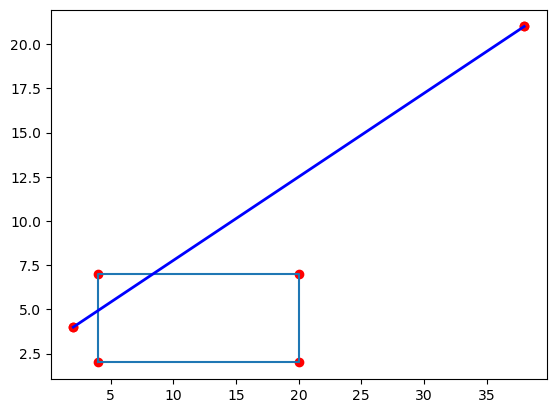

[(2, 4), -1] -> [(38, 21), -1]


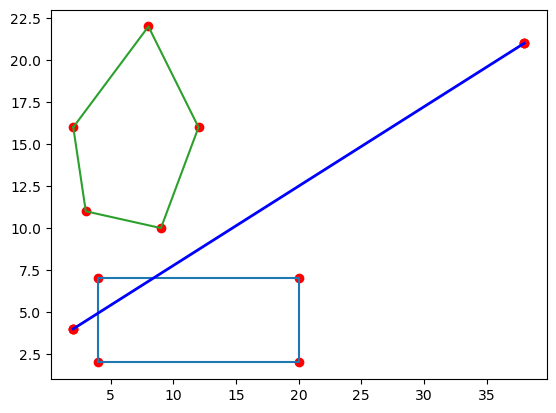

[(2, 4), -1] -> [(38, 21), -1]


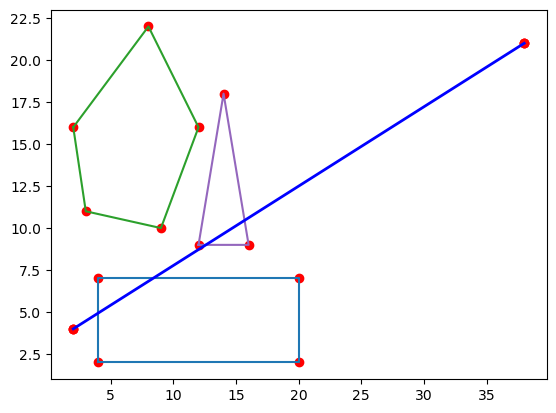

[(2, 4), -1] -> [(38, 21), -1]


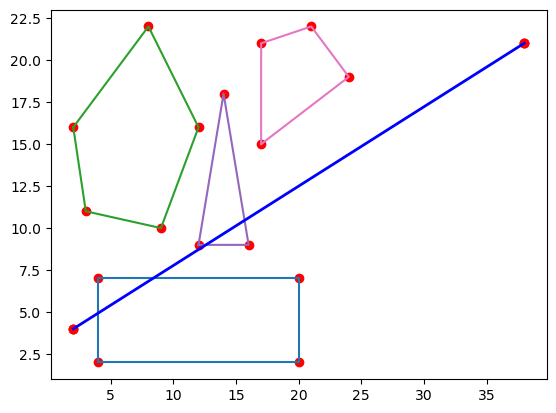

[(2, 4), -1] -> [(38, 21), -1]


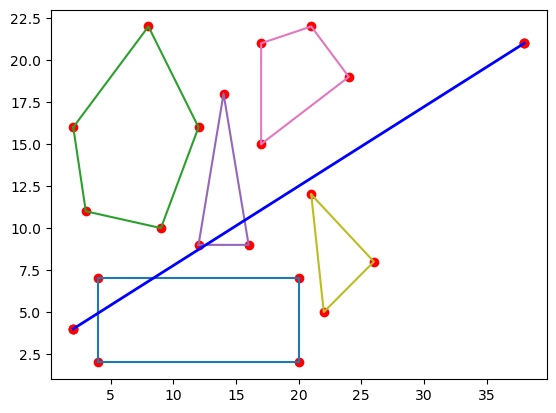

[(2, 4), -1] -> [(38, 21), -1]


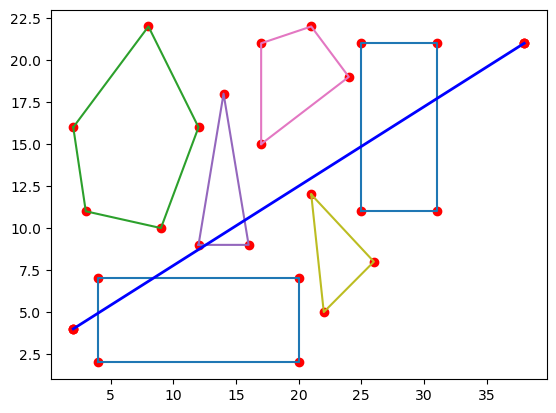

[(2, 4), -1] -> [(38, 21), -1]


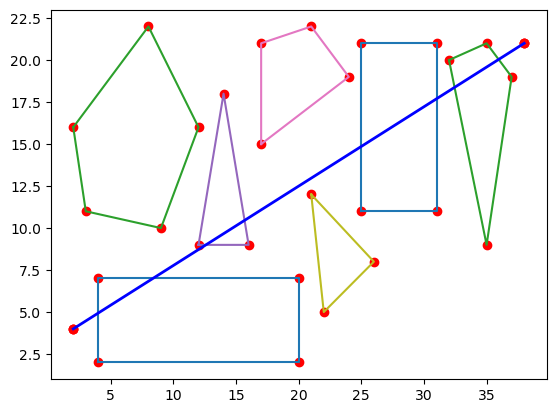

[(2, 4), -1] -> [(38, 21), -1]


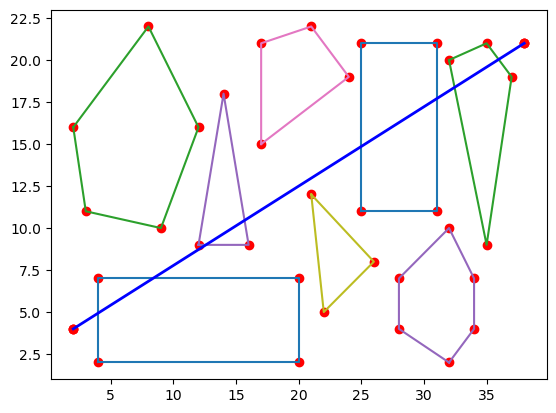

In [12]:
def main():
    n_polygon = 0
    poly_list = list(list())
    x = list()
    y = list()
    with open('Input.txt', 'r') as f:
        line = f.readline()
        line = line.strip()
        line = line.split()
        line = list(map(int, line))
        n_polygon = line[0]
        start = Point(line[1], line[2])
        goal = Point(line[3], line[4])
        poly_list.append([start])
        for line in f:
            point_list = list()
            line = line.split()
            n_vertex = int(line[0])
            for j in range(0, 2*n_vertex, 2):
                point_list.append(Point(int(line[j+1]), int(line[j +2])))
            poly_list.append(point_list[:])
            poly_list.append([goal])
            graph = Graph(poly_list)
            graph.heuristic = {point: point.heuristic(goal) for point in graph.get_points()}

            a = search(graph, start, goal, a_star)

            result = list()
            
            while a:
                result.append(a)
                a = a.pre
            result.reverse()
            print_res = [[point, point.polygon_id] for point in result]
            print(*print_res, sep = ' -> ')
            plt.figure()
            plt.plot([start.x], [start.y], 'ro')
            plt.plot([goal.x], [goal.y], 'ro')

            for point in graph.get_points():
                x.append(point.x)
                y.append(point.y)
            plt.plot(x, y, 'ro')
            for i in range(1, len(poly_list) -1):
                coord = list()
                for point in poly_list[i]:
                    coord.append([point.x, point.y])
                coord.append(coord[0])
                xs, ys = zip(*coord) # create lists of x and y values
                plt.plot(xs, ys)

            x = list()
            y = list()

            for point in result:
                x.append(point.x)
                y.append(point.y)
            plt.plot(x, y, 'b', linewidth=2.0)
            plt.show()

if __name__ == '__main__':
    main()

/var/folders/s2/tr8rp49x6n55zdz1_59v5pj40000gn/T/ipykernel_20634/3478190811.py:102: DeprecationWarning: NotImplemented should not be used in a boolean context
  return list(filter(None.__ne__, [edge.get_adjacent(point) for edge in self.edges]))


[(2, 4), -1] -> [(4, 7), 0] -> [(16, 9), 2] -> [(24, 19), 3] -> [(25, 21), 5] -> [(31, 21), 5] -> [(35, 21), 6] -> [(38, 21), -1]
Tổng chi phí đường đi: 43.814


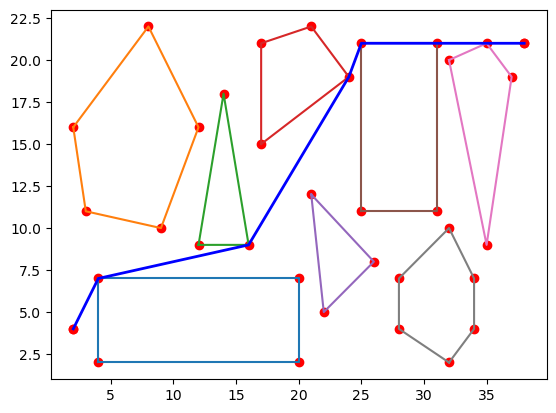

In [18]:
from collections import defaultdict
from queue import Queue, PriorityQueue
import math
from matplotlib import pyplot as plt

class Point(object):
    def __init__(self, x, y, polygon_id = -1):
        self.x = x
        self.y = y
        self.polygon_id = polygon_id
        self.g = 0
        self.pre = None
    def rel(self, other ,line):
        return line.d(self) * line.d(other) >= 0
    
    def can_see(self, other, line):  # hàm kiểm tra xem điểm other có thể nhìn thấy điểm self không 
        l1 = self.line_to(line.p1) # tạo đoạn thẳng từ self đến p1
        l2 = self.line_to(line.p2) # tạo đoạn thẳng từ self đến p2
        d3 = line.d(self) * line.d(other) < 0 # kiểm tra xem điểm other có nằm giữa 2 điểm của đoạn thẳng không
        d1 = other.rel(line.p2, l1) # kiểm tra xem điểm other có nằm cùng phía với điểm p2 không
        d2 = other.rel(line.p1, l2) # kiểm tra xem điểm other có nằm cùng phía với điểm p1 không
        return not (d1 and d2 and d3) # True: Nếu không có đường thẳng nào chắn ngang giữa điểm self và other, False: Nếu có đường thẳng chắn giữa hai điểm.

    def line_to(self, other):
        return Edge(self, other)

    def heuristic(self, other):
        return euclid_distance(self, other)

    def __eq__(self, point):
        return point and self.x == point.x and self.y == point.y
    
    def __ne__(self, point):
        return not self.__eq__(point)

    def __lt__(self, point):
        return hash(self) < hash(point)

    def __str__(self):
        return "(%d, %d)" % (self.x, self.y)
    
    def __hash__(self):
        return self.x.__hash__() ^ self.y.__hash__()
    
    def __repr__(self):
        return "(%d, %d)" % (self.x, self.y)
    

class Edge(object):
    def __init__(self, point1, point2):
        self.p1 = point1
        self.p2 = point2

    def get_adjacent(self, point):  # xác định điểm liền kề của một điểm thuộc đoạn thẳng: nếu point là p1 thì trả về p2, ngược lại trả về p1
        if point == self.p1:
            return self.p2
        if point == self.p2:
            return self.p1
    
    def d(self, point): # hàm tính khoảng cách từ một điểm đến một đoạn thẳng
        vect_a = Point(self.p2.x - self.p1.x, self.p2.y - self.p1.y) # vect_a là vector chỉ phương của đoạn thẳng
        vect_n = Point(-vect_a.y, vect_a.x) # vect_n là vector pháp tuyến của đoạn thẳng
        return vect_n.x * (point.x - self.p1.x) + vect_n.y * (point.y - self.p1.y) 

    def __str__(self):
        return "({}, {})".format(self.p1, self.p2)

    def __contains__(self, point): # hàm kiểm tra xem một điểm có thuộc đoạn thẳng không
        return self.p1 == point or self.p2 == point

    def __hash__(self):
        return self.p1.__hash__() ^ self.p2.__hash__()
    
    def __repr__(self):
        return "Edge({!r}, {!r})".format(self.p1, self.p2)


class  Graph:
    def __init__(self, polygons):
        self.graph = defaultdict(set)
        self.edges = set()
        self.polygons = defaultdict(set)
        pid = 0
        for polygon in polygons: # xây dựng đồ thị từ các đa giác
            if len(polygon) == 2: # nếu đa giác chỉ có 2 điểm thì bỏ qua
                polygon.pop()
            if polygon[0] == polygon[-1]: # nếu điểm đầu tiên và điểm cuối cùng của đa giác trùng nhau thì thêm vào đồ thị
                self.add_point(polygon[0]) # thêm điểm vào đồ thị
            else:
                for i, point in enumerate(polygon): # thêm các cạnh của đa giác vào đồ thị
                    neighbor_point = polygon[(i + 1) % len(polygon)] # điểm kề với điểm đang xét
                    edge = Edge(point, neighbor_point) # tạo cạnh từ 2 điểm
                    if len(polygon) > 2: # nếu đa giác có nhiều hơn 2 điểm thì gán id cho các điểm
                        point.polygon_id = pid # gán id cho điểm
                        neighbor_point.polygon_id = pid # gán id cho điểm kề
                        self.polygons[pid].add(edge) # thêm cạnh vào đa giác
                    self.add_edge(edge) # thêm cạnh vào đồ thị
                if len(polygon) > 2:
                    pid += 1
    
    def get_adjacent_points(self, point): # hàm trả về các điểm liền kề của m
        return list(filter(None.__ne__, [edge.get_adjacent(point) for edge in self.edges]))

    def can_see(self, start): # hàm trả về các điểm mà điểm start có thể nhìn thấy được
        see_list = list()
        cant_see_list = list()
        for polygon in self.polygons:
            for edge in self.polygons[polygon]:
                for point in self.get_points():
                    if start == point:
                        cant_see_list.append(point)
                    if start in self.get_polygon_points(polygon):
                        for poly_point in self.get_polygon_points(polygon):
                            if poly_point not in self.get_adjacent_points(start):
                                cant_see_list.append(poly_point)
                    if point not in cant_see_list:
                        if start.can_see(point, edge):
                            if point not in see_list:
                                see_list.append(point)
                        elif point in see_list: # sửa lỗi thụt dòng 
                            see_list.remove(point)
                            cant_see_list.append(point)
                        else:                           # sưa lỗi thụt dòng
                            cant_see_list.append(point)
        return see_list # sửa lại lỗi thụt đầu dòng
        

    def reachable_points(self, start):  # hàm dùng để xác định node có thể di chuyển đến được (hợp lệ) từ node đang xét trong see_list
        """ 
        Khi xét các node có thể nhìn thấy từ node đang xét thì sẽ có các trường hợp:
        1. node có thể nhìn thấy đó nằm ở một đa giác khác với đa giác đang xét
        2. node có thể nhìn thấy đó nằm ở cùng một đa giác với đa giác đang xét
          2.1. Có cạnh nối giữa node đang xét và node có thể nhìn thấy
          2.2. Không có cạnh nối giữa node đang xét và node có thể nhìn thấy (Có nghĩa là muốn đi đến node đó phải tạo ra một đường chéo mới trong đa giác)
        Trường hợp 2.2 là một đường đi không hợp lệ
        """
        reachable_points = set()
        polygons = self.get_polygons()
        can_see = self.can_see(start)
        for point in can_see:
            if point.polygon_id != start.polygon_id:
                reachable_points.add(point)
            else:
                # kiểm tra xem có phải là node liền kề không
                if point in self.get_adjacent_points(start):
                    reachable_points.add(point)
                # kiểm tra xem có phải là node không kề có thể đi đến không (không tạo ra đường chéo)
                edge = Edge(start, point)
                if edge in polygons[start.polygon_id]:
                    reachable_points.add(point)
        return reachable_points     

    def get_polygon_points(self, index): # hàm trả về tập hợp các điểm của một đa giác
        point_set = set()
        for edge in self.polygons[index]:
            point_set.add(edge.p1)
            point_set.add(edge.p2)
        return point_set

    def get_points(self): # hàm trả về tập hợp các điểm của đồ thị
        return list(self.graph)

    def get_edges(self): # hàm trả về tập hợp các cạnh của đồ thị
        return list(self.edges)
    
    def get_polygons(self): # hàm trả về tập hợp các đa giác của đồ thị
        return self.polygons

    def add_point(self, point):
        self.graph[point].add(point)

    def add_edge(self, edge):
        self.graph[edge.p1].add(edge)
        self.graph[edge.p2].add(edge)
        self.edges.add(edge)

    def __contains__(self, item):
        if isinstance(item, Point):
            return item in self.graph
        if isinstance(item, Edge):
            return item in self.edges
        return False

    def __getitem__(self, point):
        if point in self.graph:
            return self.graph[point]
        return set()

    def __str__(self):
        res = ""
        for point in self.graph:
            res += "\n" + str(point) + ": "
            for edge in self.graph[point]:
                res += str(edge)
        return res

    def __repr__(self):
        return self.__str__()

    def h(self, point):
        heuristic = getattr(self, "heuristic", None)
        if heuristic:
            return heuristic[point]
        else:
            return -1

def euclid_distance(point1, point2): # hàm tính khoảng cách euclid giữa 2 điểm
    return round(float(math.sqrt((point1.x - point2.x) ** 2 + (point1.y - point2.y) ** 2)), 3) 

def search(graph, start, goal, func): # hàm tìm kiếm đường đi dựa theo hàm heuristic
    closed = set()
    queue = PriorityQueue()
    queue.put((0 + func(graph, start), start)) # thêm điểm start vào hàng đợi
    if start not in closed:
        closed.add(start)
    while not queue.empty():
        cost, node = queue.get() 
        
        if node == goal:
            return node

        for i in graph.reachable_points(node): # duyệt qua tất cả các điểm có thể đi tới từ node
            new_cost = node.g + euclid_distance(node, i) # chi phí mới từ start đến i
            if i not in closed or new_cost < i.g: # khi i được thăm thì thêm i vào đường đi, 
                closed.add(i)  # khi i đã được thăm nhưng chi phí mới nhỏ hơn thì cập nhật lại chi phí và node cha, dòng này để không phải duyệt lại node đã thêm khi không cần thiết
                i.g = new_cost
                i.pre = node
                new_cost = func(graph, i) # tính lại giá trị heuristic cho node i sau khi đã cập nhật chi phí g
                queue.put((new_cost, i)) # thêm vào hàng đợi 
    return node


a_star = lambda graph, i: i.g  + graph.h(i) # hàm heuristic A*
greedy = lambda graph, i: graph.h(i)  # hàm heuristic Greedy

def ucs(graph, start, goal): # hàm tìm kiếm đường đi dựa theo thuật toán UCS 
    visited = set()
    queue = PriorityQueue() # hàng đợi ưu tiên
    queue.put((0, start))
    if start not in visited:
        visited.add(start)
    while not queue.empty():
        cost, node = queue.get() # lấy ra node có chi phí nhỏ nhất
        if node == goal:
            return node
        for i in graph.reachable_points(node): # duyệt qua tất cả các điểm có thể đi tới từ node
            new_cost = node.g + euclid_distance(node, i)
            
            if i not in visited or new_cost < i.g: # khi i được thăm thì thêm i vào đường đi, 
                # khi i đã được  thăm nhưng chi phí mới nhỏ hơn thì cập nhật lại chi phí và node cha
                visited.add(i)
                i.g = new_cost
                i.pre = node
                queue.put((new_cost, i))
    return node

def bfs(graph, start, goal): # hàm tìm kiếm đường đi dựa theo thuật toán BFS 
    visited = set()
    queue = Queue()
    queue.put(start)
    if start not in visited: # nếu điểm start chưa được thăm thì thêm vào tập hợp visited
        visited.add(start)
    while not queue.empty():  
        node = queue.get()
        if node == goal:
            return node
        for i in graph.reachable_points(node): # Duyệt qua tất cả các điểm có thể đi tới từ `node`
            if i not in visited:
                visited.add(i)
                i.pre = node # Lưu điểm trước đó để hỗ trợ truy vết đường đi.
                queue.put(i) # Thêm điểm này vào hàng đợi để tiếp tục xử lý ở các bước sau


def dfs(graph, start, goal): # hàm tìm kiếm đường đi dựa theo thuật toán DFS de
    visited = set()
    stack = []
    stack.append(start)
    if start not in visited:
        visited.add(start)
    while stack:
        node = stack.pop()
        if node == goal:
            return node
        for i in graph.reachable_points(node): # Duyệt qua tất cả các điểm có thể đi tới từ `node`
            if i not in visited:
                visited.add(i)
                i.pre = node # Lưu lại điểm trước đó để có thể truy vết đường đi
                stack.append(i) # Đưa điểm này vào stack để tiếp tục thăm
    

def main():
    n_polygon = 0
    poly_list = list(list())
    x = list()
    y = list()
    with open('Input.txt', 'r') as f:
        line = f.readline()
        line = line.strip()
        line = line.split()
        line = list(map(int, line))
        n_polygon = line[0]
        start = Point(line[1], line[2])
        goal = Point(line[3], line[4])
        poly_list.append([start])
        for line in f: # xây dựng đồ thị từ file input
            point_list = list()
            line = line.split()
            n_vertex = int(line[0])
            for j in range(0, 2*n_vertex, 2):
                point_list.append(Point(int(line[j + 1]), int(line[j + 2])))
            poly_list.append(point_list[:])
        poly_list.append([goal])
        graph = Graph(poly_list)
        graph.add_point(start)
        graph.heuristic = {point: point.heuristic(goal) for point in graph.get_points()}
        
        # a = search(graph, start, goal, a_star)
        # a = search(graph, start, goal, greedy)
        a = ucs(graph, start, goal)
        # a = dfs(graph, start, goal)
        # a = bfs(graph, start, goal)


        result = list()
        total_cost = 0  # Biến lưu tổng chi phí của đường đi

        while a: # truy vết đường đi
            result.append(a)

            if a.pre:  # Nếu điểm trước đó tồn tại, tính khoảng cách Euclid
                total_cost += euclid_distance(a, a.pre)

            a = a.pre
        result.reverse()
        print_res = [[point, point.polygon_id] for point in result]
        print(*print_res, sep=' -> ')
        # In tổng chi phí của đường đi
        print(f"Tổng chi phí đường đi: {total_cost}")

        plt.figure()
        plt.plot([start.x], [start.y], 'ro')
        plt.plot([goal.x], [goal.y], 'ro')

        for point in graph.get_points(): # vẽ các điểm trên đồ thị
            x.append(point.x)
            y.append(point.y)
        plt.plot(x, y, 'ro')
        for i in range(1, len(poly_list) - 1):
            coord = list()
            for point in poly_list[i]:
                coord.append([point.x, point.y])
            coord.append(coord[0])
            xs, ys = zip(*coord) # Create lists of x and y values
            plt.plot(xs, ys)
        x = list()
        y = list()
        for point in result:
            x.append(point.x)
            y.append(point.y)
        plt.plot(x, y, 'b', linewidth=2.0)
        plt.show()

# Note: có thể gộp can_see và reachable_points thành một hàm duy nhất để tránh việc lặp lại việc duyệt qua các điểm có thể nhìn thấy

if __name__ == "__main__":
    main()